# Network Intrusion Detection System using Machine Learning

This project focuses on detecting anomalous network traffic using machine learning algorithms. 
The system analyzes network flow data and classifies whether a connection is normal or an anomaly.

### Objectives
- Detect malicious network traffic
- Compare multiple ML algorithms
- Reduce dimensionality using PCA
- Evaluate models using multiple metrics

# Basic Libraries

In [1]:
import numpy as np
import pandas as pd

# Visualization Libraries

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Importing required Sklearn techniques


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Importing Basic classification models

In [4]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Metrics

In [5]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Time

In [6]:
import time

# Ignore warnings

In [7]:
import warnings
warnings.filterwarnings("ignore")

# Loading Dataset

In [8]:
df = pd.read_csv("train_net.csv", nrows=100000)

print("Dataset Loaded")
print(df.shape)

df.head()

Dataset Loaded
(100000, 33)


,FLOW_ID,PROTOCOL_MAP,L4_SRC_PORT,IPV4_SRC_ADDR,L4_DST_PORT,IPV4_DST_ADDR,FIRST_SWITCHED,FLOW_DURATION_MILLISECONDS,LAST_SWITCHED,PROTOCOL,...,TOTAL_PKTS_EXP,TOTAL_BYTES_EXP,IN_BYTES,IN_PKTS,OUT_BYTES,OUT_PKTS,ANALYSIS_TIMESTAMP,ANOMALY,ALERT,ID
0,372018590,udp,53950,10.114.232.40,53,10.114.226.5,1647760833,1,1647760833,17,...,0,0,165,2,275,2,1647760873,0.0,NaN,0
1,368604472,tcp,37914,10.114.241.166,38303,10.114.224.218,1647686725,1,1647686725,6,...,0,0,44,1,40,1,1647687338,0.0,Port Scanning,1
2,367513992,tcp,33216,10.114.241.166,18757,10.114.224.116,1647680044,0,1647680044,6,...,0,0,44,1,40,1,1647680115,1.0,Port Scanning,2
3,371997670,udp,48627,10.114.225.205,53,10.114.226.5,1647760172,0,1647760172,17,...,0,0,128,2,160,2,1647760207,0.0,NaN,3
4,374311119,udp,35939,10.114.225.205,53,10.114.226.5,1647780916,0,1647780916,17,...,0,0,172,2,300,2,1647780984,0.0,NaN,4


# Dataset overview

In [9]:
print("Dataset Shape:", df.shape)

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
df.describe()

Dataset Shape: (100000, 33)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 33 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   FLOW_ID                     100000 non-null  int64  
 1   PROTOCOL_MAP                100000 non-null  object 
 2   L4_SRC_PORT                 100000 non-null  int64  
 3   IPV4_SRC_ADDR               100000 non-null  object 
 4   L4_DST_PORT                 100000 non-null  int64  
 5   IPV4_DST_ADDR               100000 non-null  object 
 6   FIRST_SWITCHED              100000 non-null  int64  
 7   FLOW_DURATION_MILLISECONDS  100000 non-null  int64  
 8   LAST_SWITCHED               100000 non-null  int64  
 9   PROTOCOL                    100000 non-null  int64  
 10  TCP_FLAGS                   100000 non-null  int64  
 11  TCP_WIN_MAX_IN              100000 non-null  int64  
 12  TCP_WIN_MAX_OUT        

,FLOW_ID,L4_SRC_PORT,L4_DST_PORT,FIRST_SWITCHED,FLOW_DURATION_MILLISECONDS,LAST_SWITCHED,PROTOCOL,TCP_FLAGS,TCP_WIN_MAX_IN,TCP_WIN_MAX_OUT,...,MAX_IP_PKT_LEN,TOTAL_PKTS_EXP,TOTAL_BYTES_EXP,IN_BYTES,IN_PKTS,OUT_BYTES,OUT_PKTS,ANALYSIS_TIMESTAMP,ANOMALY,ID
count,1.000000e+05,100000.000000,100000.000000,1.000000e+05,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.0,100000.0,100000.0,1.000000e+05,100000.000000,1.000000e+05,100000.00000,1.000000e+05,54886.000000,100000.000000
mean,3.548809e+08,42068.015160,8473.546070,1.647568e+09,5829.512300,1.647568e+09,10.289750,10.461270,10751.670410,8027.946650,...,0.0,0.0,0.0,1.329382e+04,36.782210,7.712188e+04,61.09607,1.647569e+09,0.180283,49999.500000
std,1.770575e+07,19248.502121,17073.124088,1.729249e+05,22242.796419,1.729240e+05,5.946902,15.024709,23192.630499,20199.506245,...,0.0,0.0,0.0,7.675917e+05,1209.559159,3.428253e+06,2376.18527,1.725069e+05,0.384426,28867.657797
min,4.000000e+00,0.000000,0.000000,1.647330e+09,0.000000,1.647330e+09,1.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,2.800000e+01,1.000000,0.000000e+00,0.00000,1.647330e+09,0.000000,0.000000
25%,3.384315e+08,34857.750000,53.000000,1.647412e+09,0.000000,1.647412e+09,6.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,5.600000e+01,1.000000,4.000000e+01,1.00000,1.647412e+09,0.000000,24999.750000
50%,3.674046e+08,49232.000000,443.000000,1.647680e+09,3.000000,1.647680e+09,6.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,9.800000e+01,1.000000,1.280000e+02,1.00000,1.647680e+09,0.000000,49999.500000
75%,3.702876e+08,55792.000000,5938.000000,1.647709e+09,145.000000,1.647709e+09,17.000000,22.000000,1024.000000,271.000000,...,0.0,0.0,0.0,2.400000e+02,3.000000,3.660000e+02,2.00000,1.647709e+09,0.000000,74999.250000
max,3.743763e+08,65533.000000,65530.000000,1.648190e+09,119999.000000,1.648190e+09,57.000000,223.000000,65535.000000,65535.000000,...,0.0,0.0,0.0,1.340241e+08,154786.000000,4.742026e+08,316143.00000,1.648226e+09,1.000000,99999.000000


# Finding Missing values

In [10]:
print("Missing Values:\n")

print(df.isnull().sum())

Missing Values:

FLOW_ID                           0
PROTOCOL_MAP                      0
L4_SRC_PORT                       0
IPV4_SRC_ADDR                     0
L4_DST_PORT                       0
IPV4_DST_ADDR                     0
FIRST_SWITCHED                    0
FLOW_DURATION_MILLISECONDS        0
LAST_SWITCHED                     0
PROTOCOL                          0
TCP_FLAGS                         0
TCP_WIN_MAX_IN                    0
TCP_WIN_MAX_OUT                   0
TCP_WIN_MIN_IN                    0
TCP_WIN_MIN_OUT                   0
TCP_WIN_MSS_IN                    0
TCP_WIN_SCALE_IN                  0
TCP_WIN_SCALE_OUT                 0
SRC_TOS                           0
DST_TOS                           0
TOTAL_FLOWS_EXP                   0
MIN_IP_PKT_LEN                    0
MAX_IP_PKT_LEN                    0
TOTAL_PKTS_EXP                    0
TOTAL_BYTES_EXP                   0
IN_BYTES                          0
IN_PKTS                           0
OUT_BYTES  

# Target Variable Distribution

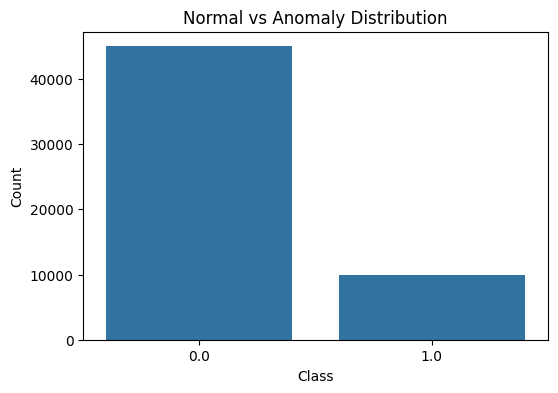

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(x=df["ANOMALY"])

plt.title("Normal vs Anomaly Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.savefig("normal_vs_Anomaly.png", dpi=300, bbox_inches='tight')
plt.show()

# feature distribution

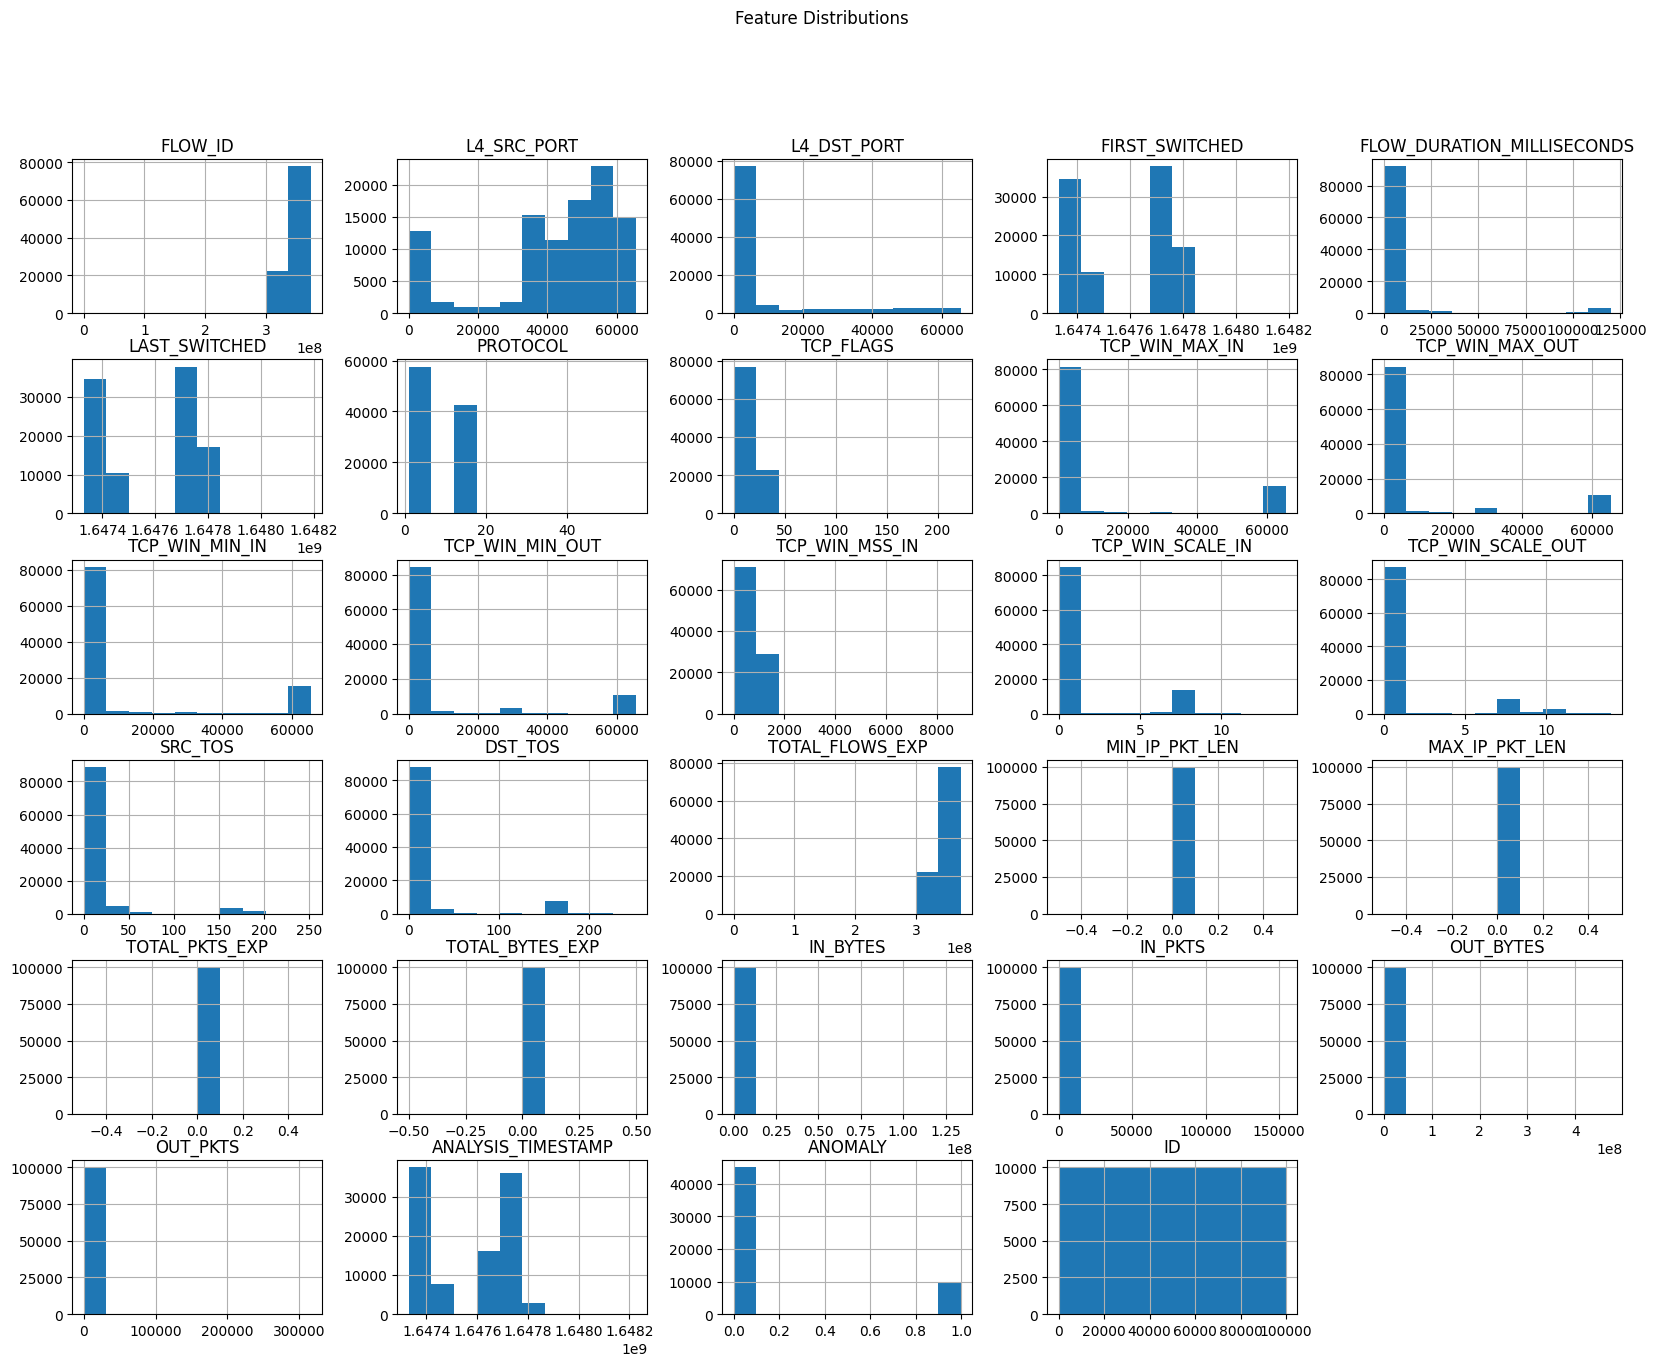

In [12]:
df.hist(figsize=(20,15))

plt.suptitle("Feature Distributions")
plt.savefig("feature_distribution.png", dpi=400, bbox_inches='tight')

plt.show()

# Drop unneccessary columns

In [13]:
drop_cols = [
    "FLOW_ID",
    "IPV4_SRC_ADDR",
    "IPV4_DST_ADDR",
    "ID"
]

df = df.drop(columns=drop_cols)

In [14]:
df = df.replace("None", np.nan)

df = df.fillna(0)

In [15]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
le = LabelEncoder()

df["PROTOCOL_MAP"] = le.fit_transform(df["PROTOCOL_MAP"].astype(str))
df["ALERT"] = le.fit_transform(df["ALERT"].astype(str))

# Define Target and Features

In [16]:
target = "ANOMALY"

X = df.drop(target, axis=1)
y = df[target].astype(int)

# Train Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (80000, 28)
Testing Shape: (20000, 28)


# Feature Engineering Techniques

In [18]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Feature Scaling

In [19]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# PCA(Dimensionality Reduction)

In [20]:
pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_scaled)

X_test_pca = pca.transform(X_test_scaled)

print("Original Features:", X_train.shape[1])
print("Reduced Features:", X_train_pca.shape[1])

Original Features: 28
Reduced Features: 12


# PCA Explained Variance Visualization

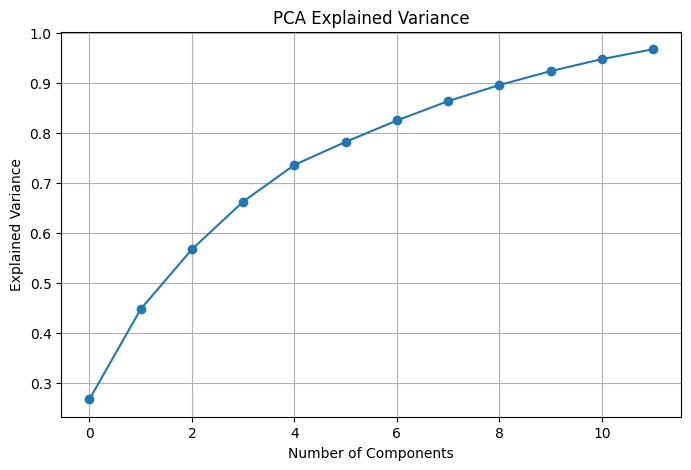

In [21]:
plt.figure(figsize=(8,5))

plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')

plt.title("PCA Explained Variance")

plt.xlabel("Number of Components")

plt.ylabel("Explained Variance")

plt.grid()

plt.savefig("PCA_variance.png", dpi=300, bbox_inches='tight')

plt.show()

# Advanced Algorithms

In [22]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# KNN Model

Training KNN Model
Accuracy: 0.9796

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.98      0.99     18021
           1       0.87      0.93      0.90      1979

    accuracy                           0.98     20000
   macro avg       0.93      0.96      0.94     20000
weighted avg       0.98      0.98      0.98     20000



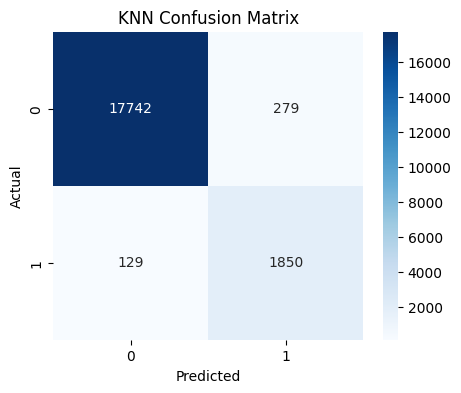

In [23]:
print("Training KNN Model")

start = time.time()

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_pca, y_train)

end = time.time()

knn_time = end - start

knn_pred = knn_model.predict(X_test_pca)

knn_acc = accuracy_score(y_test, knn_pred)

print("Accuracy:", knn_acc)

print("\nClassification Report\n")
print(classification_report(y_test, knn_pred))

cm = confusion_matrix(y_test, knn_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("KNN_model.png", dpi=300, bbox_inches='tight')

plt.show()

# Decision Tree Model

Training Decision Tree
Accuracy: 0.9777

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.98      0.99     18021
           1       0.84      0.95      0.89      1979

    accuracy                           0.98     20000
   macro avg       0.92      0.97      0.94     20000
weighted avg       0.98      0.98      0.98     20000



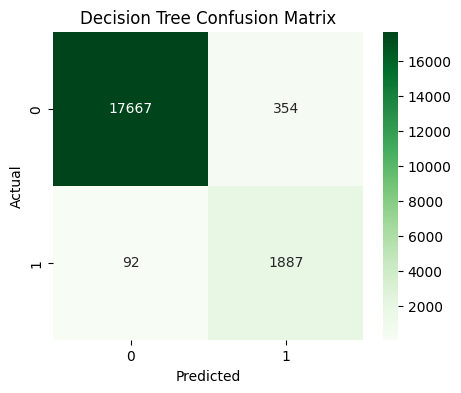

In [24]:
print("Training Decision Tree")

start = time.time()

dt_model = DecisionTreeClassifier(max_depth=15)

dt_model.fit(X_train_pca, y_train)

end = time.time()

dt_time = end - start

dt_pred = dt_model.predict(X_test_pca)

dt_acc = accuracy_score(y_test, dt_pred)

print("Accuracy:", dt_acc)

print("\nClassification Report\n")
print(classification_report(y_test, dt_pred))

cm = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("Decision_model.png", dpi=300, bbox_inches='tight')
plt.show()

# XGBoost Model

Training XGBoost
Accuracy: 0.9828

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     18021
           1       0.86      0.98      0.92      1979

    accuracy                           0.98     20000
   macro avg       0.93      0.98      0.95     20000
weighted avg       0.98      0.98      0.98     20000



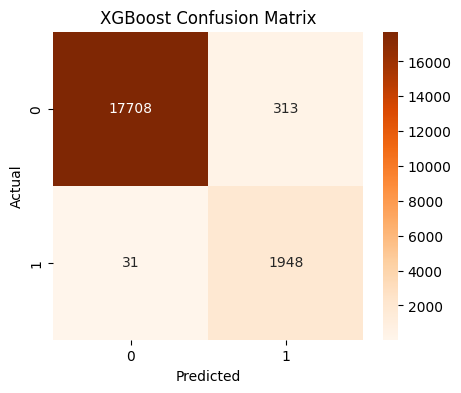

In [25]:
print("Training XGBoost")

start = time.time()

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_pca, y_train)

end = time.time()

xgb_time = end - start

xgb_pred = xgb_model.predict(X_test_pca)

xgb_acc = accuracy_score(y_test, xgb_pred)

print("Accuracy:", xgb_acc)

print("\nClassification Report\n")
print(classification_report(y_test, xgb_pred))

cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("XGBoost_model.png", dpi=300, bbox_inches='tight')
plt.show()

# LightGBM Model

Training LightGBM
[LightGBM] [Info] Number of positive: 7916, number of negative: 72084
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005589 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3060
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.098950 -> initscore=-2.208946
[LightGBM] [Info] Start training from score -2.208946
Accuracy: 0.9825

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     18021
           1       0.86      0.98      0.92      1979

    accuracy                           0.98     20000
   macro avg       0.93      0.98      0.95     20000
weighted avg       0.98      0.98      0.98     20000



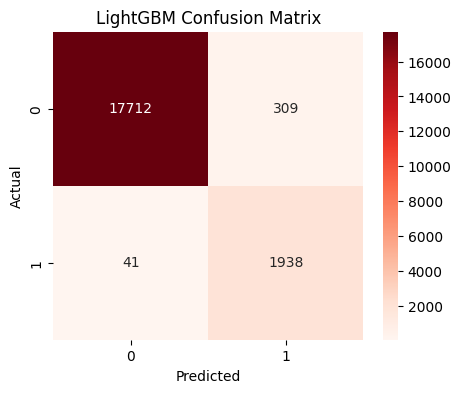

In [26]:
print("Training LightGBM")

start = time.time()

lgbm_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

lgbm_model.fit(X_train_pca, y_train)

end = time.time()

lgbm_time = end - start

lgbm_pred = lgbm_model.predict(X_test_pca)

lgbm_acc = accuracy_score(y_test, lgbm_pred)

print("Accuracy:", lgbm_acc)

print("\nClassification Report\n")
print(classification_report(y_test, lgbm_pred))

cm = confusion_matrix(y_test, lgbm_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds")

plt.title("LightGBM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("LightGBM_model.png", dpi=300, bbox_inches='tight')
plt.show()

# CatBoost Model

Training CatBoost
Accuracy: 0.98235

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     18021
           1       0.86      0.98      0.92      1979

    accuracy                           0.98     20000
   macro avg       0.93      0.98      0.95     20000
weighted avg       0.98      0.98      0.98     20000



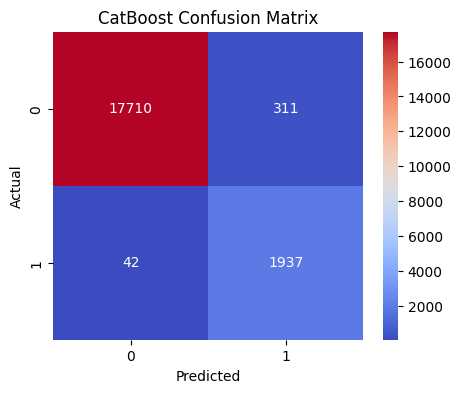

In [27]:
print("Training CatBoost")

start = time.time()

cat_model = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.1,
    verbose=False
)

cat_model.fit(X_train_pca, y_train)

end = time.time()

cat_time = end - start

cat_pred = cat_model.predict(X_test_pca)

cat_acc = accuracy_score(y_test, cat_pred)

print("Accuracy:", cat_acc)

print("\nClassification Report\n")
print(classification_report(y_test, cat_pred))

cm = confusion_matrix(y_test, cat_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm")

plt.title("CatBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("Catboost_model.png", dpi=300, bbox_inches='tight')
plt.show()

# Random Forest

Training Random Forest...
Training completed in: 1.75 seconds
Accuracy: 0.99925

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18021
           1       1.00      0.99      1.00      1979

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



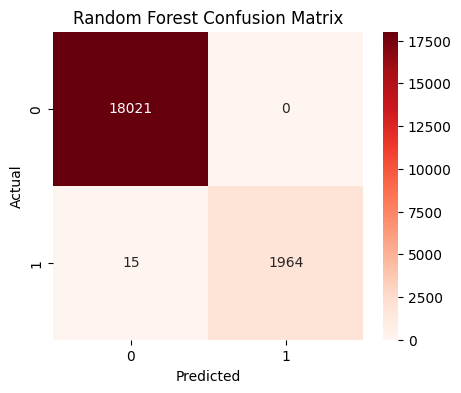

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import time

# Initialize model
rf_model = RandomForestClassifier(
    n_estimators=100,        # number of trees
    max_depth=None,          # tree depth (None = grow fully)
    class_weight="balanced", # useful for imbalanced datasets
    random_state=42,
    n_jobs=-1                # use all CPU cores
)

print("Training Random Forest...")

start_time = time.time()

# Train model
rf_model.fit(X_train, y_train)

end_time = time.time()

print("Training completed in:", round(end_time - start_time, 2), "seconds")

# Predictions
y_pred = rf_model.predict(X_test)

# Evaluation
rf_acc = accuracy_score(y_test, y_pred)

print("Accuracy:", rf_acc)

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

rf = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(rf, annot=True, fmt="d", cmap="Reds")

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("RandomForest_model.png", dpi=300, bbox_inches='tight')
plt.show()

# ROC_Curve Implementation

In [29]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

In [30]:
models = {
    "KNN": knn_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model,
    "CatBoost": cat_model
}

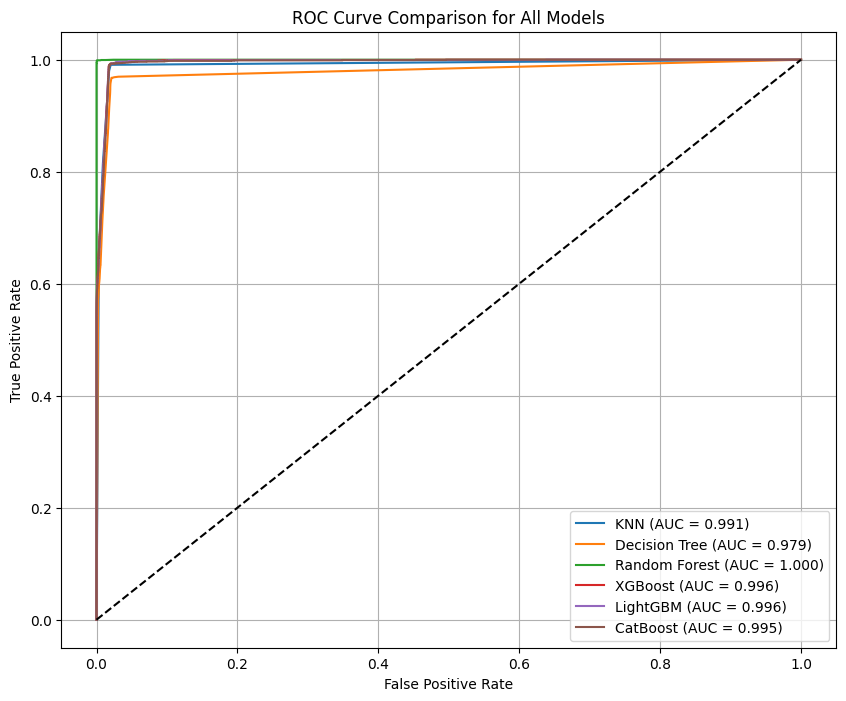

In [31]:
plt.figure(figsize=(10,8))

for name, model in models.items():
    
    expected_features = model.n_features_in_
    
    if expected_features == X_test.shape[1]:
        X_eval = X_test
    elif expected_features == X_test_pca.shape[1]:
        X_eval = X_test_pca
    else:
        print(f"Skipping {name}")
        continue
    
    try:
        y_prob = model.predict_proba(X_eval)[:,1]
    except:
        print(f"{name} does not support predict_proba")
        continue
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

# random classifier line
plt.plot([0,1],[0,1],'k--')

plt.title("ROC Curve Comparison for All Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.savefig("Roc_curve.png", dpi=300, bbox_inches='tight')
plt.show()

# Implementation of Explainable AI Using Shap & LIME

In [32]:
import shap
print(shap.__version__)

0.44.1


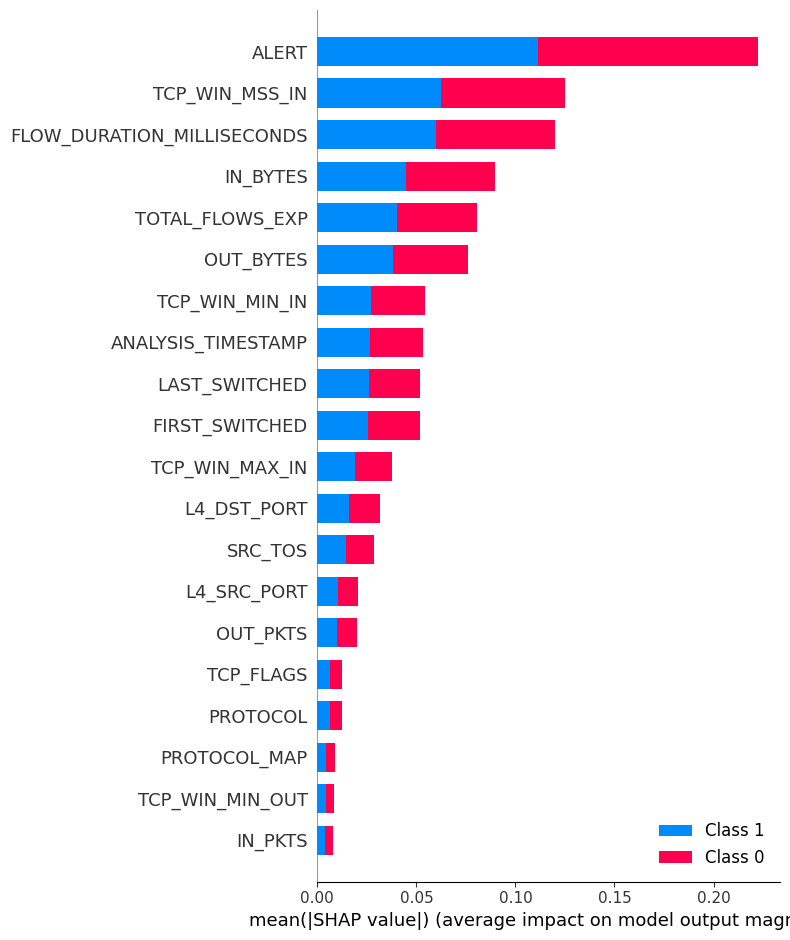

In [37]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, show=False)

plt.savefig("shap_summary_plot.png", dpi=300, bbox_inches='tight')
plt.show()

# SHAP Dependence Plot → Feature behavior analysis

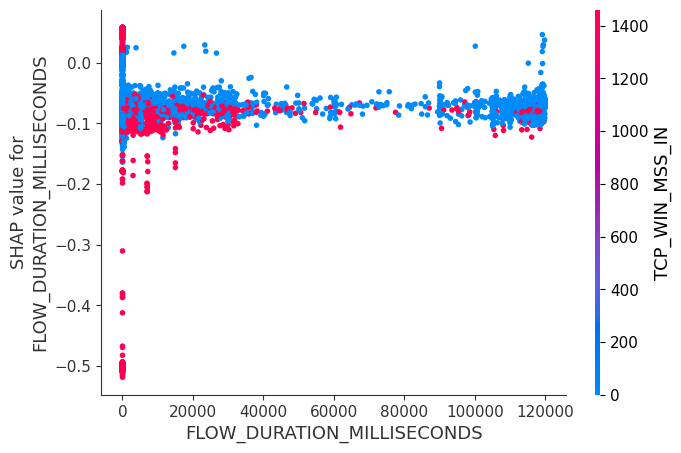

In [42]:
shap.dependence_plot(
    "FLOW_DURATION_MILLISECONDS",
    shap_values[1],
    X_test,
    show=False
)

plt.savefig("shap_dependence_flow_duration.png", dpi=300, bbox_inches='tight')
plt.show()

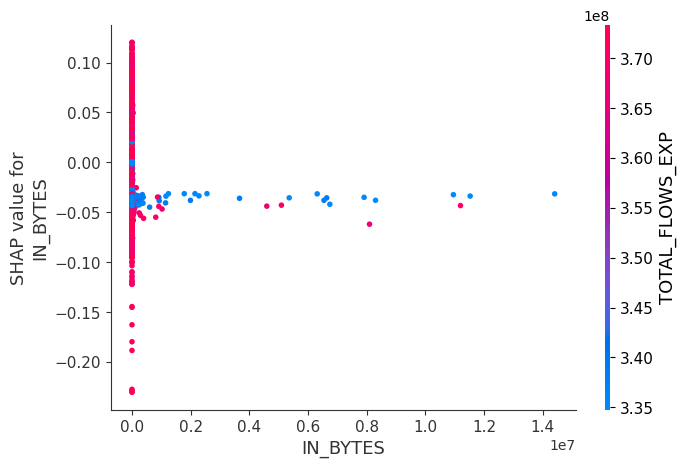

In [41]:


shap.dependence_plot("IN_BYTES", shap_values[1], X_test, show=False)

plt.savefig("shap_dependence_plot.png", dpi=300, bbox_inches='tight')
plt.show()

In [34]:
from lime.lime_tabular import LimeTabularExplainer
import numpy as np

# define feature names
feature_names = X_train.columns.tolist()

# create explainer
lime_explainer = LimeTabularExplainer(
    X_train.values,
    feature_names=feature_names,
    class_names=["Class 0","Class 1"],
    mode="classification"
)

# explain one test instance
exp = lime_explainer.explain_instance(
    X_test.iloc[0].values,
    rf_model.predict_proba,
    num_features=10
)

# show explanation
exp.show_in_notebook(show_table=True)

# Checking for Overfitting using difference between training & testing accuracies

In [35]:
from sklearn.metrics import accuracy_score

# training prediction
y_train_pred = rf_model.predict(X_train)

# testing prediction
y_test_pred = rf_model.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 1.0
Testing Accuracy: 0.99925
